<a href="https://colab.research.google.com/github/adenurchalisa/Air-Quality-Analysis/blob/main/bismillah_bisa_otw_hasil_layer_23_fixxx_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PERSIAPAN DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount.


**Menentukan Path dan Mengecek Dataset**

In [ ]:
import os

# path folder dataset di Drive
DATA_DIR = '/content/drive/MyDrive/Ummul Khatima/Dataset_Fake_Real'

# mengecek folder Real dan Fake
print("Isi folder dataset:")
for folder in os.listdir(DATA_DIR):
    full = os.path.join(DATA_DIR, folder)
    if os.path.isdir(full):
        jumlah = len([f for f in os.listdir(full)
                      if f.lower().endswith(('.jpg','.jpeg','.png','.webp','.bmp'))])
        print(f"  📁 {folder} : {jumlah} gambar")

Isi folder dataset:
  📁 Fake : 5000 gambar
  📁 Real : 5000 gambar


In [ ]:
# Label: 0 = Real, 1 = Fake
class_folders = {'Real': 0, 'Fake': 1}

all_paths, all_labels = [], []
for folder, label in class_folders.items():
    folder_path = os.path.join(DATA_DIR, folder)
    files = sorted([f for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp'))])
    for f in files:
        all_paths.append(os.path.join(folder_path, f))
        all_labels.append(label)

print(f"✅ Total gambar terbaca : {len(all_paths)}")
print(f"   Real (label 0)       : {all_labels.count(0)}")
print(f"   Fake (label 1)       : {all_labels.count(1)}")

✅ Total gambar terbaca : 10000
   Real (label 0)       : 5000
   Fake (label 1)       : 5000


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(20)

# **Preprocessing**

**Pembagian Data**

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 20

# Split pertama: train (70%) vs sisanya (30%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

# Split kedua: sisa 30% dibagi rata jadi val (15%) dan test (15%)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("✅ Pembagian data selesai (stratified 70:15:15):\n")
print(f"  Train : {len(train_paths):>4} gambar  ->  Real {train_labels.count(0)} | Fake {train_labels.count(1)}")
print(f"  Val   : {len(val_paths):>4} gambar  ->  Real {val_labels.count(0)} | Fake {val_labels.count(1)}")
print(f"  Test  : {len(test_paths):>4} gambar  ->  Real {test_labels.count(0)} | Fake {test_labels.count(1)}")
print(f"\n  Total : {len(train_paths)+len(val_paths)+len(test_paths)} gambar" )

✅ Pembagian data selesai (stratified 70:15:15):

  Train : 7000 gambar  ->  Real 3500 | Fake 3500
  Val   : 1500 gambar  ->  Real 750 | Fake 750
  Test  : 1500 gambar  ->  Real 750 | Fake 750

  Total : 10000 gambar


NORMALISASI DAN AUGMENTASI

In [ ]:
from torchvision import transforms

# Nilai normalisasi standar ImageNet
# Wajib dipakai karena Swin-T sudah dilatih awal (pretrained) dengan distribusi ini
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Transform untuk DATA LATIH (dengan augmentasi)
# Urutan: resize -> augmentasi -> ubah ke tensor -> normalisasi
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),              # samakan ukuran ke 224x224 (input Swin-T)
    transforms.RandomHorizontalFlip(p=0.5),     # augmentasi: balik horizontal 50%
    transforms.RandomRotation(degrees=15),      # augmentasi: rotasi acak maksimal 15 derajat
    transforms.ToTensor(),                      # konversi gambar ke tensor, skala [0,1]
    transforms.Normalize(mean=mean, std=std),   # normalisasi dengan mean & std ImageNet
])

# Transform untuk DATA VALIDASI & UJI (TANPA augmentasi)
# Hanya resize, ubah ke tensor, dan normalisasi
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("Transform berhasil didefinisikan.")
print("- train_transform : dengan augmentasi (flip + rotasi)")
print("- eval_transform  : tanpa augmentasi (untuk val & test)")

Transform berhasil didefinisikan.
- train_transform : dengan augmentasi (flip + rotasi)
- eval_transform  : tanpa augmentasi (untuk val & test)


Memuat Dataset

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

# Kelas Dataset khusus untuk dataset
# Tugasnya mengambil 1 gambar berdasarkan indeks, baca, konversi RGB, lalu transform
class AIDetectionDataset(Dataset):

    def __init__(self, paths, labels, transform):
        self.paths = paths          # daftar lokasi file gambar
        self.labels = labels        # daftar label (0=real, 1=fake)
        self.transform = transform  # resep transform (train atau eval)

    def __len__(self):
        # mengembalikan jumlah total gambar
        return len(self.paths)

    def __getitem__(self, idx):
        # membaca gambar ke-idx dari path-nya
        image = Image.open(self.paths[idx]).convert('RGB')  # convert RGB: tangani semua format
        image = self.transform(image)                        # menerapkan transform
        label = self.labels[idx]
        return image, label


# membuat objek dataset untuk masing-masing bagian
# Data latih pakai train_transform (ada augmentasi)
# Data val & test pakai eval_transform (tanpa augmentasi)
train_dataset = AIDetectionDataset(train_paths, train_labels, train_transform)
val_dataset   = AIDetectionDataset(val_paths,   val_labels,   eval_transform)
test_dataset  = AIDetectionDataset(test_paths,  test_labels,  eval_transform)

print("Dataset berhasil dibuat:")
print(f"- train_dataset : {len(train_dataset)} gambar (dengan augmentasi)")
print(f"- val_dataset   : {len(val_dataset)} gambar (tanpa augmentasi)")
print(f"- test_dataset  : {len(test_dataset)} gambar (tanpa augmentasi)")

Dataset berhasil dibuat:
- train_dataset : 7000 gambar (dengan augmentasi)
- val_dataset   : 1500 gambar (tanpa augmentasi)
- test_dataset  : 1500 gambar (tanpa augmentasi)


**Memuat dataload**

In [ ]:
from torch.utils.data import DataLoader

# Ukuran batch: berapa gambar diproses sekaligus dalam satu langkah
batch_size = 32

# DataLoader untuk data latih
# shuffle=True : acak urutan tiap epoch supaya model tidak menghafal urutan
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2          # jumlah proses paralel untuk memuat data
)

# DataLoader untuk validasi & uji
# shuffle=False : tidak perlu diacak karena hanya untuk evaluasi
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("DataLoader berhasil dibuat:")
print(f"- train_loader : {len(train_loader)} batch")
print(f"- val_loader   : {len(val_loader)} batch")
print(f"- test_loader  : {len(test_loader)} batch")

# Uji ambil satu batch untuk memastikan semuanya bekerja
images, labels = next(iter(train_loader))
print(f"\nUji satu batch:")
print(f"- Bentuk batch gambar : {images.shape}")   # harusnya [32, 3, 224, 224]
print(f"- Bentuk batch label  : {labels.shape}")   # harusnya [32]

DataLoader berhasil dibuat:
- train_loader : 219 batch
- val_loader   : 47 batch
- test_loader  : 47 batch

Uji satu batch:
- Bentuk batch gambar : torch.Size([32, 3, 224, 224])
- Bentuk batch label  : torch.Size([32])


# **Implementasi Transfer learning dengan swin**

**Memuat Model**

In [ ]:
import timm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")

# Nama arsitektur Swin-T di timm
model_name = 'swin_tiny_patch4_window7_224'

# Muat model dengan bobot pretrained ImageNet
# pretrained=True : unduh bobot hasil latihan di ImageNet dari HuggingFace Hub
model = timm.create_model(model_name, pretrained=True)

# Pindahkan model ke device (GPU/CPU)
model = model.to(device)

print(f"\nModel '{model_name}' berhasil dimuat.")
print(f"Jumlah parameter total: {sum(p.numel() for p in model.parameters()):,}")

Device yang digunakan: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Model 'swin_tiny_patch4_window7_224' berhasil dimuat.
Jumlah parameter total: 28,288,354


**Menyesuaikan Layer Output 2 kelas**

In [ ]:
import torch.nn as nn

# struktur head asli model (output untuk 1000 kelas ImageNet)
print("Head asli model:")
print(model.head)

# Ambil jumlah fitur input ke layer head (in_features)
# ukuran vektor fitur yang dihasilkan backbone Swin-T
jumlah_fitur = model.head.fc.in_features
print(f"\nJumlah fitur dari backbone: {jumlah_fitur}")

# menganti layer output dari 1000 kelas menjadi 2 kelas (real & fake)
model.head.fc = nn.Linear(jumlah_fitur, 2)

# Pindahkan layer baru ke device yang sama
model = model.to(device)

print(f"\nHead setelah disesuaikan:")
print(model.head)
print(f"\nLayer output berhasil diubah menjadi 2 kelas (0=Real, 1=Fake).")

Head asli model:
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=1000, bias=True)
  (flatten): Identity()
)

Jumlah fitur dari backbone: 768

Head setelah disesuaikan:
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=2, bias=True)
  (flatten): Identity()
)

Layer output berhasil diubah menjadi 2 kelas (0=Real, 1=Fake).


# **Konfigurasi Training**

**Pembekuan layer**

In [ ]:
# Strategi: bekukan stage awal, latih hanya stage akhir + head
# Tujuan: hemat komputasi & cegah overfitting karena data kita relatif kecil (3000)

# Langkah 1: bekukan SEMUA parameter dulu
for param in model.parameters():
    param.requires_grad = False

# Langkah 2: buka kembali (unfreeze) hanya bagian yang ingin dilatih:
# - 'layers.3' : stage terakhir Swin-T (paling dekat ke output)
# - 'head'     : layer klasifikasi 2 kelas yang kita buat di Tahap 4
# - 'norm'     : layer normalisasi akhir
# layers.0 dan layers.1 tetap dibekukan (fitur dasar dari ImageNet sudah cukup)
for name, param in model.named_parameters():
    if ('layers.2' in name or 'layers.3' in name or
        'head' in name or name.startswith('norm')):
        param.requires_grad = True

# Verifikasi: hitung parameter yang dilatih vs total
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameter      : {total_params:,}")
print(f"Parameter dilatih    : {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Parameter dibekukan  : {total_params - trainable_params:,}")

Total parameter      : 27,520,892
Parameter dilatih    : 26,325,050 (95.7%)
Parameter dibekukan  : 1,195,842


In [ ]:
import torch.nn as nn

# Hyperparameter
learning_rate = 5e-5
weight_decay  = 0.05      # regularisasi untuk mencegah overfitting
epochs        = 50        # jumlah putaran latihan maksimal

# Loss function untuk klasifikasi: CrossEntropyLoss
# Cocok untuk klasifikasi 2 kelas (real/fake)
criterion = nn.CrossEntropyLoss()

# Optimizer: AdamW
# Hanya melatih parameter yang requires_grad=True (stage akhir + head)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Scheduler: menurunkan learning rate secara bertahap tiap epoch
# CosineAnnealing membuat LR mengecil mengikuti kurva cosinus
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print("Konfigurasi training siap:")
print(f"- Loss      : CrossEntropyLoss")
print(f"- Optimizer : AdamW (lr={learning_rate}, weight_decay={weight_decay})")
print(f"- Scheduler : CosineAnnealingLR")
print(f"- Epochs    : {epochs}")

Konfigurasi training siap:
- Loss      : CrossEntropyLoss
- Optimizer : AdamW (lr=5e-05, weight_decay=0.05)
- Scheduler : CosineAnnealingLR
- Epochs    : 50


# **Fine Tuning**

In [ ]:
import os, time

# Folder untuk menyimpan model terbaik di Google Drive
save_dir = '/content/drive/MyDrive/Ummul Khatima/skripsi_model'
os.makedirs(save_dir, exist_ok=True)

# Riwayat metrik untuk grafik
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Pengaturan early stopping
patience = 10                   # berhenti jika val acc tak membaik 10 epoch berturut-turut
best_val_acc = 0.0
epoch_tanpa_perbaikan = 0

print("Memulai fine-tuning...\n")

for epoch in range(1, epochs + 1):
    waktu_mulai = time.time()

    # ---------- FASE LATIH ----------
    model.train()                              # aktifkan mode latih (augmentasi & dropout aktif)
    train_loss, train_benar, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                  # reset gradien dari langkah sebelumnya
        outputs = model(images)                # model membuat prediksi
        loss = criterion(outputs, labels)      # hitung seberapa salah prediksinya
        loss.backward()                        # hitung gradien (arah perbaikan)
        optimizer.step()                       # perbarui bobot model

        train_loss += loss.item() * images.size(0)
        train_benar += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_benar / train_total

    # ---------- FASE VALIDASI ----------
    model.eval()                               # aktifkan mode evaluasi (augmentasi & dropout mati)
    val_loss, val_benar, val_total = 0.0, 0, 0

    with torch.no_grad():                      # tidak menghitung gradien (hemat memori, lebih cepat)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_benar += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_benar / val_total

    scheduler.step()                           # turunkan learning rate untuk epoch berikutnya

    # Simpan riwayat metrik
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    durasi = time.time() - waktu_mulai
    print(f"Epoch {epoch:2d}/{epochs} | "
          f"train: loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val: loss {val_loss:.4f} acc {val_acc:.4f} | {durasi:.0f}s")

    # ---------- SIMPAN MODEL TERBAIK + EARLY STOPPING ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epoch_tanpa_perbaikan = 0
        torch.save(model.state_dict(), f'{save_dir}/modelswin.pth')
        print(f"   -> model terbaik disimpan (val acc {val_acc:.4f})")
    else:
        epoch_tanpa_perbaikan += 1
        if epoch_tanpa_perbaikan >= patience:
            print(f"\nEarly stopping di epoch {epoch} "
                  f"(val acc tidak membaik {patience} epoch berturut-turut)")
            break

print(f"\nFine-tuning selesai. Akurasi validasi terbaik: {best_val_acc:.4f}")
print(f"Model tersimpan di: {save_dir}/modelswin.pth")

Memulai fine-tuning...

Epoch  1/50 | train: loss 0.2617 acc 0.8859 | val: loss 0.1363 acc 0.9460 | 900s
   -> model terbaik disimpan (val acc 0.9460)
Epoch  2/50 | train: loss 0.1018 acc 0.9610 | val: loss 0.1553 acc 0.9373 | 100s
Epoch  3/50 | train: loss 0.0705 acc 0.9746 | val: loss 0.1978 acc 0.9347 | 100s
Epoch  4/50 | train: loss 0.0478 acc 0.9830 | val: loss 0.1290 acc 0.9547 | 100s
   -> model terbaik disimpan (val acc 0.9547)
Epoch  5/50 | train: loss 0.0358 acc 0.9853 | val: loss 0.1166 acc 0.9647 | 102s
   -> model terbaik disimpan (val acc 0.9647)
Epoch  6/50 | train: loss 0.0347 acc 0.9866 | val: loss 0.1036 acc 0.9647 | 102s
Epoch  7/50 | train: loss 0.0220 acc 0.9921 | val: loss 0.1416 acc 0.9627 | 100s
Epoch  8/50 | train: loss 0.0237 acc 0.9913 | val: loss 0.1135 acc 0.9680 | 100s
   -> model terbaik disimpan (val acc 0.9680)
Epoch  9/50 | train: loss 0.0118 acc 0.9964 | val: loss 0.2155 acc 0.9453 | 104s
Epoch 10/50 | train: loss 0.0203 acc 0.9933 | val: loss 0.1200 

✅ Grafik tersimpan di: /content/drive/MyDrive/Ummul Khatima/grafik_modelswin.png


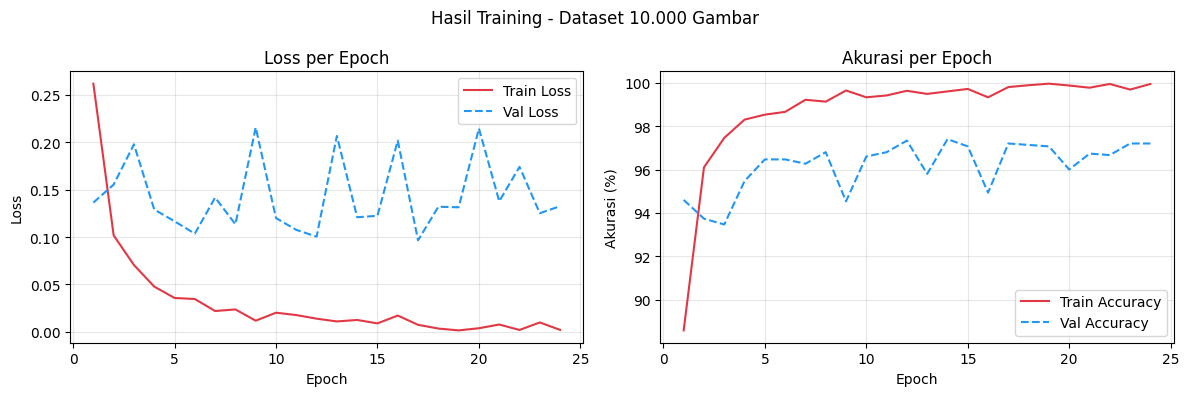

✅ History tersimpan di: /content/drive/MyDrive/Ummul Khatima/grafik_modelswin.json


In [ ]:
# ============================================================
# GRAFIK LOSS DAN AKURASI - VERSI SEDERHANA
# jalankan tepat setelah training selesai
# pastikan variabel 'history' masih ada di sesi Colab
# ============================================================

import matplotlib.pyplot as plt

# ambil data dari history training
train_loss = history['train_loss']
val_loss   = history['val_loss']
train_acc  = history['train_acc']
val_acc    = history['val_acc']

epochs = list(range(1, len(train_loss) + 1))

# konversi akurasi ke persen
train_acc_pct = [x * 100 for x in train_acc]
val_acc_pct   = [x * 100 for x in val_acc]

# buat grafik 1 baris 2 kolom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ------- grafik loss -------
ax1.plot(epochs, train_loss, label='Train Loss', color='#E23744')
ax1.plot(epochs, val_loss,   label='Val Loss',   color='#2196F3', linestyle='--')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ------- grafik akurasi -------
ax2.plot(epochs, train_acc_pct, label='Train Accuracy', color='#E23744')
ax2.plot(epochs, val_acc_pct,   label='Val Accuracy',   color='#2196F3', linestyle='--')
ax2.set_title('Akurasi per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Akurasi (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Hasil Training - Dataset 10.000 Gambar', fontsize=12)
plt.tight_layout()

# simpan ke Drive
path_simpan = '/content/drive/MyDrive/Ummul Khatima/grafik_modelswin.png'
plt.savefig(path_simpan, dpi=150, bbox_inches='tight', facecolor='white')
print(f"✅ Grafik tersimpan di: {path_simpan}")

plt.show()

# simpan history ke Drive agar tidak hilang
import json
path_history = '/content/drive/MyDrive/Ummul Khatima/grafik_modelswin.json'
with open(path_history, 'w') as f:
    json.dump(history, f)
print(f"✅ History tersimpan di: {path_history}")

**Uji model dengan data uji**

In [ ]:
import torch
import numpy as np

# Muat kembali bobot model TERBAIK
model.load_state_dict(torch.load(f'{save_dir}/modelswin.pth', map_location=device))
model = model.to(device)
model.eval()   # mode evaluasi: matikan augmentasi & dropout

# Siapkan wadah untuk menampung semua prediksi dan label asli
semua_pred = []
semua_label = []

# Jalankan model pada seluruh data uji
with torch.no_grad():                          # tanpa hitung gradien (hanya menguji)
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)                # model membuat prediksi
        preds = outputs.argmax(1).cpu()        # ambil kelas dengan skor tertinggi (0 atau 1)

        semua_pred.extend(preds.numpy())
        semua_label.extend(labels.numpy())

# Ubah ke array numpy agar mudah dihitung
semua_pred = np.array(semua_pred)
semua_label = np.array(semua_label)

# Hitung akurasi pada data uji
akurasi_uji = (semua_pred == semua_label).mean()

print(f"Jumlah data uji   : {len(semua_label)}")
print(f"Akurasi data uji  : {akurasi_uji:.4f} ({akurasi_uji*100:.2f}%)")

Jumlah data uji   : 1500
Akurasi data uji  : 0.9780 (97.80%)


# **Visualisasi GradCAM**

**Setup GradCAM dan Visualisasi**

In [ ]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Pastikan model dalam kondisi terbaik dan mode evaluasi
model.load_state_dict(torch.load(f'{save_dir}/modelswin.pth', map_location=device))
model.eval()

# Fungsi reshape: ubah output token Swin menjadi format peta 2D agar bisa dibaca GradCAM
# Swin mengeluarkan fitur dalam bentuk token, bukan grid spasial seperti CNN
def reshape_transform(tensor):
    if tensor.dim() == 4:                       # format [B, H, W, C]
        result = tensor.permute(0, 3, 1, 2)     # ubah ke [B, C, H, W]
    else:                                       # format [B, L, C]
        B, L, C = tensor.shape
        H = W = int(L ** 0.5)
        result = tensor.reshape(B, H, W, C).permute(0, 3, 1, 2)
    return result

# Target layer: layer norm di blok terakhir stage akhir Swin-T
target_layers = [model.layers[-1].blocks[-1].norm2]

# Buat objek GradCAM
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

label_nama = {0: 'Real', 1: 'Fake'}
print("Setup GradCAM selesai.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Setup GradCAM selesai.


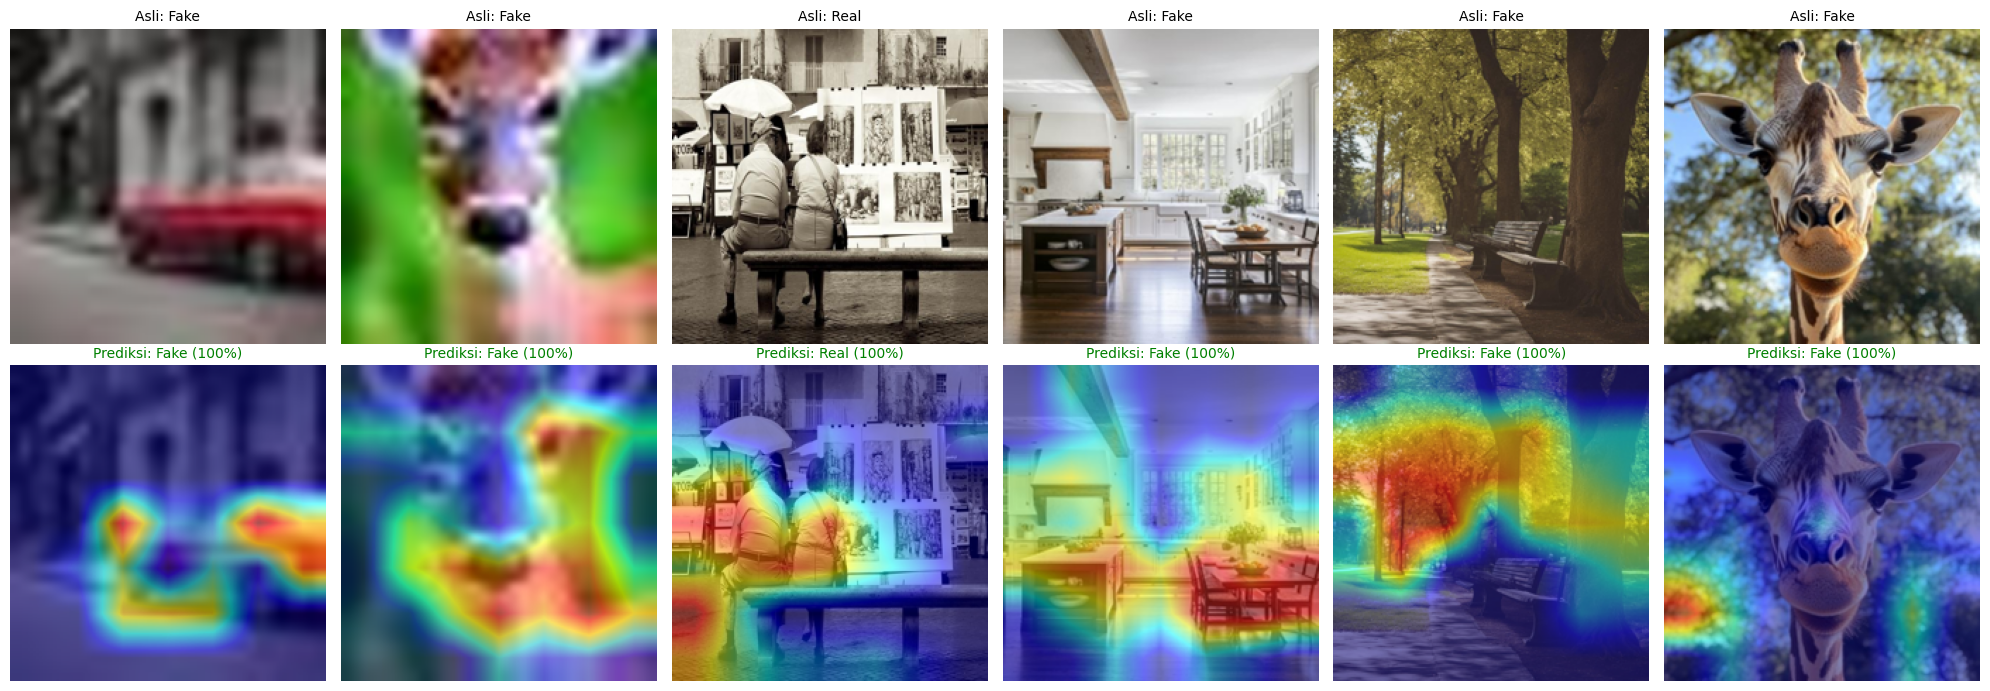

Visualisasi GradCAM selesai. Gambar tersimpan di Drive.


In [ ]:
# Fungsi menyiapkan gambar: satu untuk ditampilkan, satu untuk input model
def siapkan_gambar(path):
    img = Image.open(path).convert('RGB')
    # versi tampilan: resize 224, skala 0-1, TANPA normalisasi (untuk overlay heatmap)
    img_display = np.array(img.resize((224, 224)), dtype=np.float32) / 255.0
    # versi input model: DENGAN normalisasi (pakai eval_transform dari Tahap 2)
    input_tensor = eval_transform(img).unsqueeze(0).to(device)
    return img_display, input_tensor

# Ambil 6 contoh dari data uji
contoh_paths = test_paths[:6]
contoh_labels = test_labels[:6]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, (path, label_asli) in enumerate(zip(contoh_paths, contoh_labels)):
    img_display, input_tensor = siapkan_gambar(path)

    # prediksi model
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()
        prob = torch.softmax(output, 1)[0, pred].item()

    # hitung heatmap GradCAM untuk kelas yang diprediksi
    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # tempelkan heatmap ke gambar asli
    visualisasi = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    # baris atas: gambar asli
    axes[0, i].imshow(img_display)
    axes[0, i].set_title(f"Asli: {label_nama[label_asli]}", fontsize=10)
    axes[0, i].axis('off')

    # baris bawah: heatmap (judul hijau jika benar, merah jika salah)
    warna = 'green' if pred == label_asli else 'red'
    axes[1, i].imshow(visualisasi)
    axes[1, i].set_title(f"Prediksi: {label_nama[pred]} ({prob*100:.0f}%)",
                         fontsize=10, color=warna)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{save_dir}/gradcammodelswin.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualisasi GradCAM selesai. Gambar tersimpan di Drive.")

# **Confusion Matrix**

Confusion Matrix (angka):
[[727  23]
 [ 10 740]]


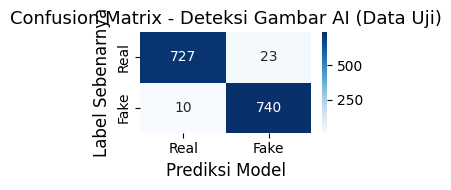

Confusion matrix tersimpan di Drive.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung confusion matrix dari prediksi vs label asli (data uji)
cm = confusion_matrix(semua_label, semua_pred)

print("Confusion Matrix (angka):")
print(cm)

# Visualisasikan dalam bentuk heatmap agar mudah dibaca
plt.figure(figsize=(3, 2))
sns.heatmap(
    cm,
    annot=True,            # tampilkan angka di tiap kotak
    fmt='d',               # format angka bulat
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    cbar=True
)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Label Sebenarnya', fontsize=12)
plt.title('Confusion Matrix - Deteksi Gambar AI (Data Uji)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{save_dir}/confusionswin.png', dpi=100, bbox_inches='tight')
plt.show()

print("Confusion matrix tersimpan di Drive.")

# **Performa model**

**Metrik klasifikasi**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

nama_kelas = ['Real', 'Fake']

# Laporan lengkap precision, recall, f1 untuk tiap kelas
print("=== LAPORAN KLASIFIKASI (Data Uji) ===\n")
print(classification_report(semua_label, semua_pred, target_names=nama_kelas, digits=4))

# Ringkasan dengan kelas positif = Fake (label 1)
akurasi  = accuracy_score(semua_label, semua_pred)
presisi  = precision_score(semua_label, semua_pred, pos_label=1)
recall   = recall_score(semua_label, semua_pred, pos_label=1)
f1       = f1_score(semua_label, semua_pred, pos_label=1)

print("=== RINGKASAN (kelas positif = Fake) ===")
print(f"Akurasi   : {akurasi:.4f} ({akurasi*100:.2f}%)")
print(f"Precision : {presisi:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

=== LAPORAN KLASIFIKASI (Data Uji) ===

              precision    recall  f1-score   support

        Real     0.9864    0.9693    0.9778       750
        Fake     0.9699    0.9867    0.9782       750

    accuracy                         0.9780      1500
   macro avg     0.9781    0.9780    0.9780      1500
weighted avg     0.9781    0.9780    0.9780      1500

=== RINGKASAN (kelas positif = Fake) ===
Akurasi   : 0.9780 (97.80%)
Precision : 0.9699
Recall    : 0.9867
F1-Score  : 0.9782


**Metrik Efisiensi**

In [ ]:
!pip install thop -q
import time, os, torch

# 1. Jumlah parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 2. Ukuran file model di disk
ukuran_mb = os.path.getsize(f'{save_dir}/modelswin.pth') / (1024**2)

# 3. Waktu inferensi rata-rata per gambar
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():                  # pemanasan (warm-up)
    for _ in range(10):
        _ = model(dummy)

if device.type == 'cuda':
    torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    for _ in range(100):
        _ = model(dummy)
if device.type == 'cuda':
    torch.cuda.synchronize()
waktu_inferensi = (time.time() - t0) / 100 * 1000   # ms per gambar

print("=== METRIK EFISIENSI ===")
print(f"Total parameter      : {total_params:,}")
print(f"Parameter dilatih    : {trainable_params:,}")
print(f"Ukuran model (disk)  : {ukuran_mb:.2f} MB")
print(f"Waktu inferensi      : {waktu_inferensi:.2f} ms/gambar")
print(f"Throughput           : {1000/waktu_inferensi:.1f} gambar/detik")

# 4. FLOPs (opsional, bisa gagal di sebagian versi library)
try:
    from thop import profile
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
    print(f"FLOPs (GFLOPs)       : {flops/1e9:.2f}")
except Exception as e:
    print(f"FLOPs                : tidak dihitung ({type(e).__name__})")

=== METRIK EFISIENSI ===
Total parameter      : 27,520,892
Parameter dilatih    : 26,325,050
Ukuran model (disk)  : 105.05 MB
Waktu inferensi      : 26.69 ms/gambar
Throughput           : 37.5 gambar/detik
FLOPs (GFLOPs)       : 4.37
